# Annotation in Scanpy

In [1]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [2]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.1] # This takes a while per res

2025-02-01 12:51:53,413 - INFO - Plate variable detected: plate1
2025-02-01 12:51:53,417 - INFO - Processing plate: plate1



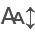

2025-02-01 12:51:53,474 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-02-01 12:51:53,475 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-02-01 12:51:53,475 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-02-01 12:51:53,476 - INFO - Scanpy directory exists: True
2025-02-01 12:51:53,477 - INFO - Sheets directory: /Users/darren/Desktop/eQTL_study_2025/resources/sheets/
2025-02-01 12:51:53,477 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-02-01 12:51:53,478 - INFO - Loading data ...


(5225, 587)

In [3]:
# Initialize the environment and get all paths and logger
logger, root_dir, sheets_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")
adata = sc.read(scanpy_dir + f'adata_clusters.h5ad')
adata.shape

In [4]:
# Violin plots of gene expression

2025-02-01 12:51:53,823 - INFO - Plot Violin ...


Genes not found in dataset for gene set Nowak_fig4: C1QC, TTR, PECAM1, TBX18, OMG, CSPG5, GHR, FZD8, HJURP, CRYAB, HEPACAM, LMO1, LEF1, VEPH1, NEUROG1, NRN1, BEST3, PIF1, ASCL1, EOMES, CALB2, SP8, SST, LINCO1305, TAC3, LHX6, NDST4, SLN, RSPO3, KCNJ6, NEFM, NEFL, HCRTR2, CRYM, TRPM3, PKD1, NHLH1
Genes not found in dataset for gene set Poulio_fig1c: RGS5, CCL3, AIF1, ITM2A, CLDN5, ESAM, DLX1, DLX2, LHX6, DLX5, STMN2, NEUROD6, PPP1R17, SSTR2, EOMES, PENK, STMN2, NEUROD6, NEUROD6, POU2F2, HMGB2, SOX2, MKI67, PCNA, OLIG1, PDGFRA, VIM, SOX2, SLC1A3, HES1, HOPX
Genes not found in dataset for gene set Camer_PFC: GAD1, SLC17A7, EOMES, GLI3, OLIG1, MKI67, C3, ITM2A, SST, CALB2, SCGN, TLE3, FEZF2, CRYM, LHX2
Genes not found in dataset for gene set ExNs: BCL11B, TBR1, NEUROD6, CPNE8
Genes not found in dataset for gene set InNs: GAD1, GAD2, DLX1, DLX2, SOX6, CALB1, CALB2, LHX6, PROX1
Genes not found in dataset for gene set Oligos: MBP, MOG, PLP1, MAG, CNP, OLIG1, OLIG2
Genes not found in dataset fo

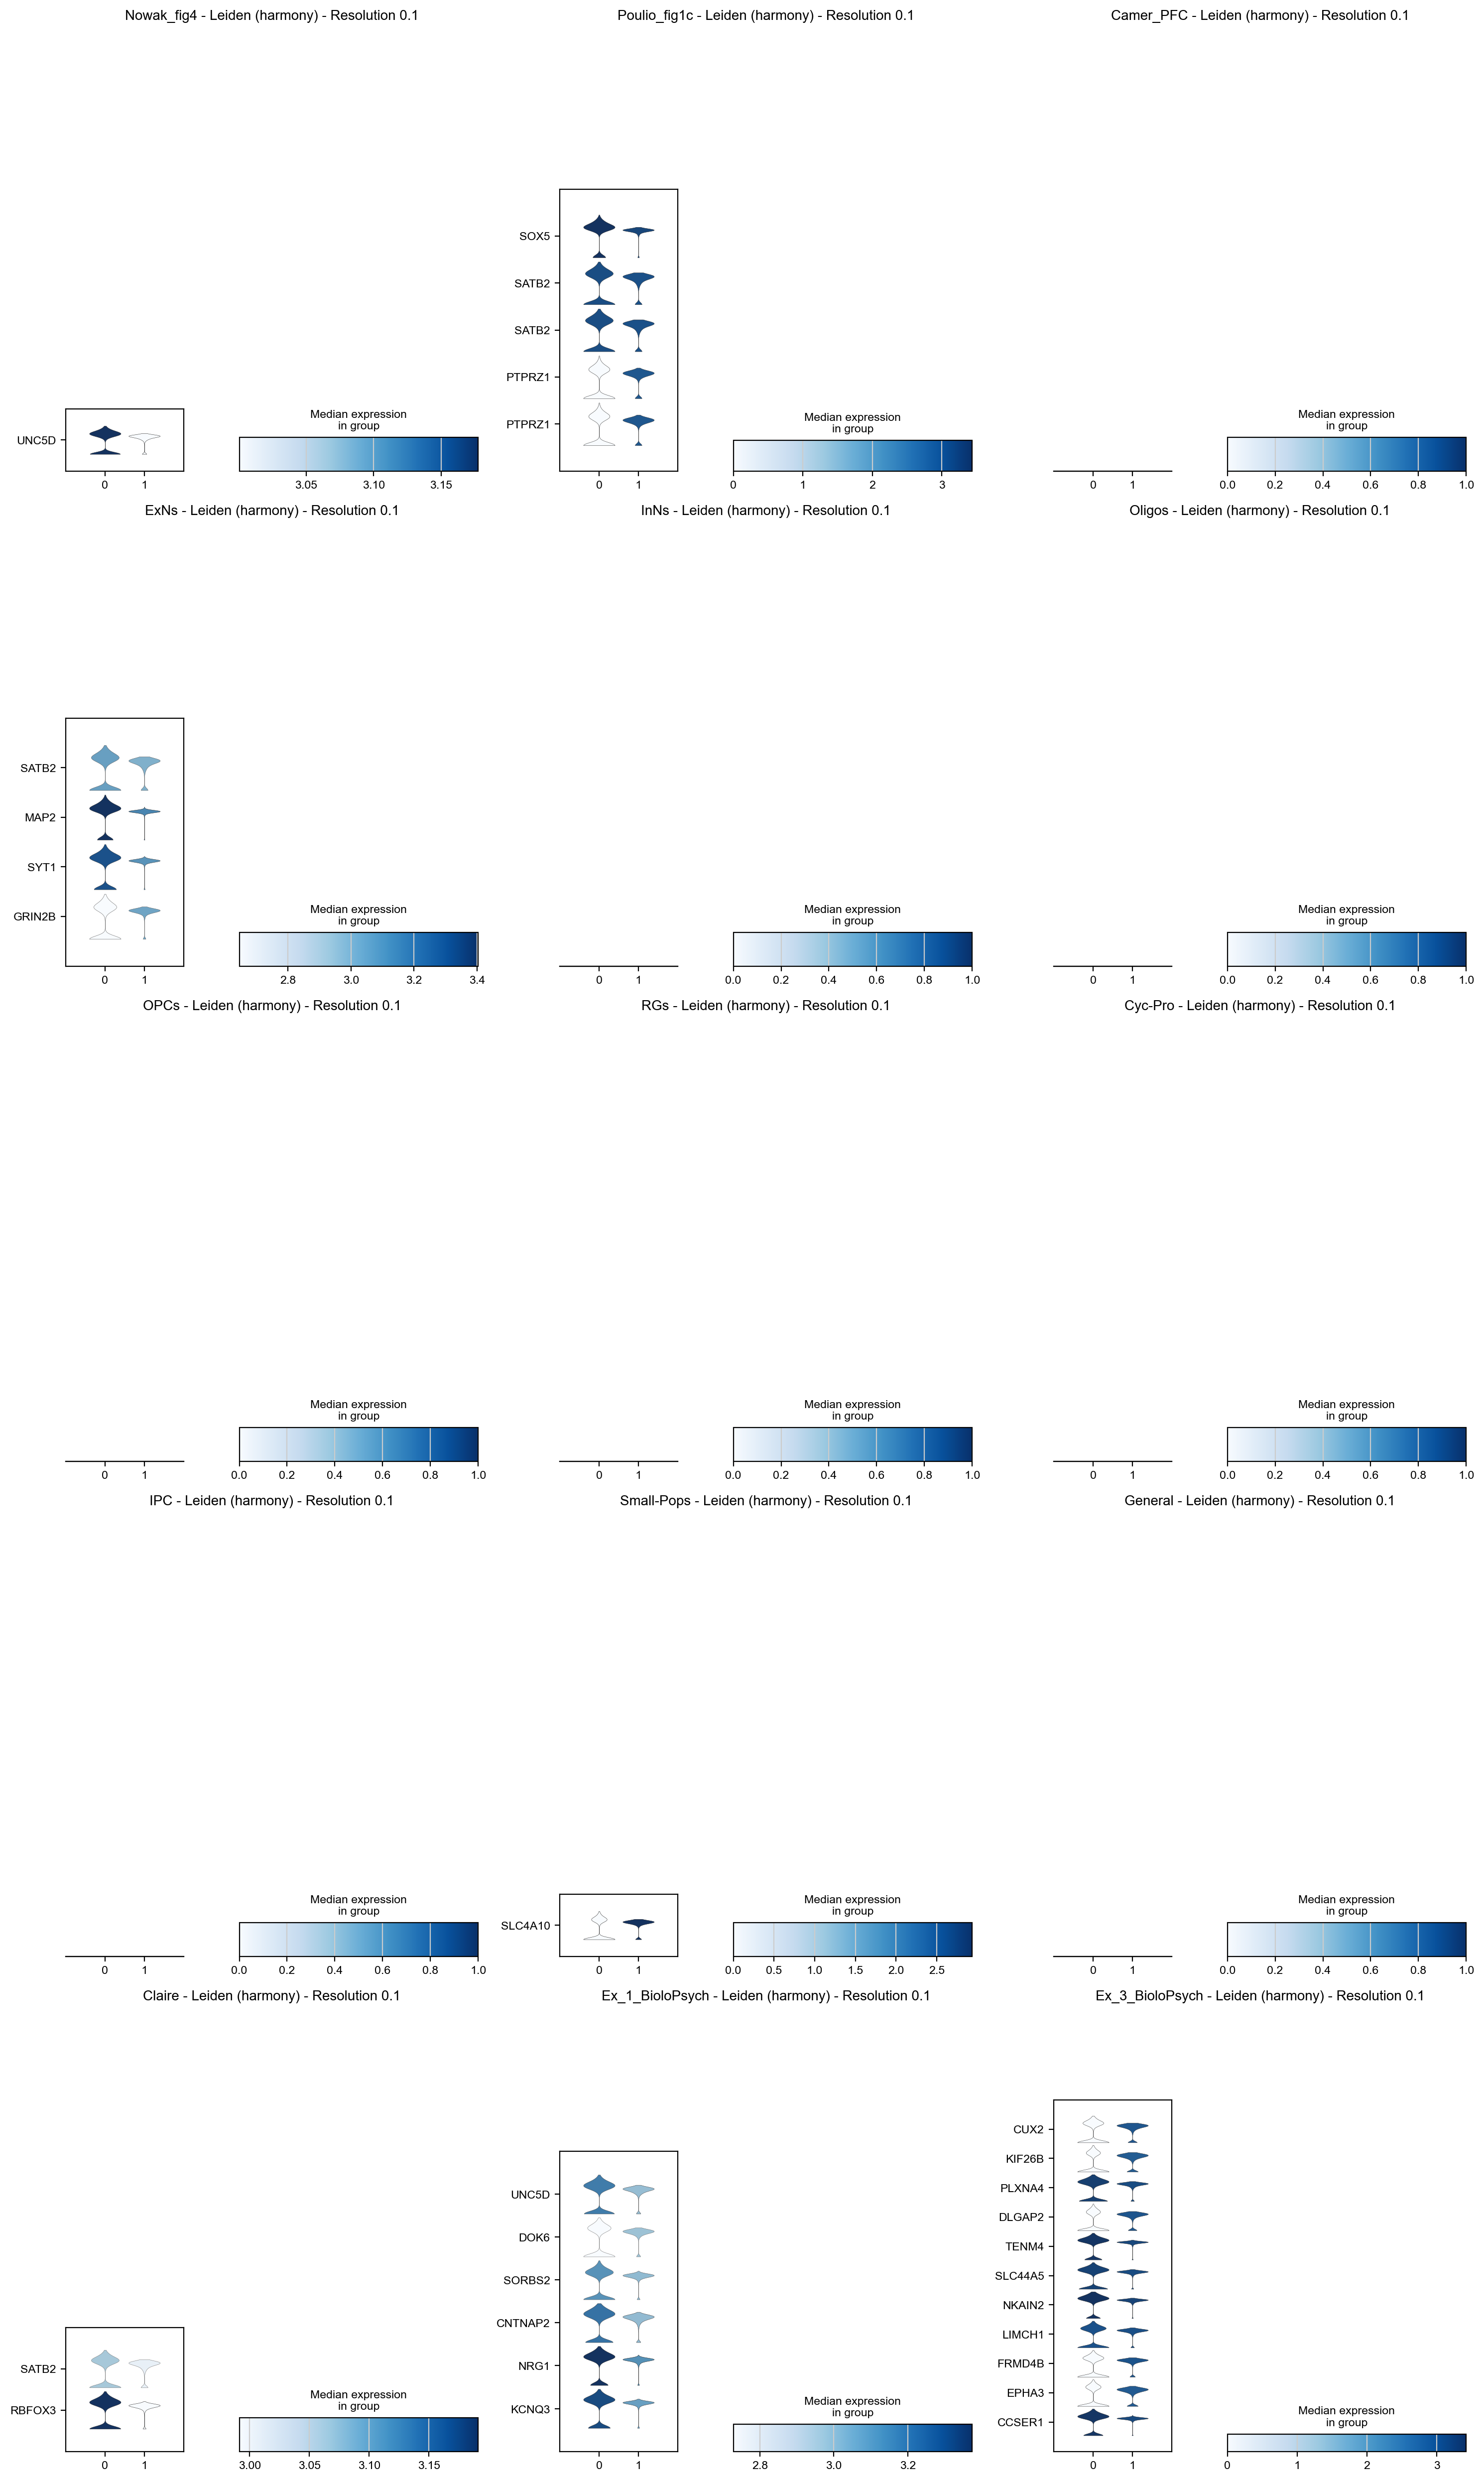

In [5]:
# Violin plots
logger.info("Plot Violin ...")
gene_sets = [("Nowak_fig4", Nowakowski_Fig4A_genes), 
             ("Poulio_fig1c", Pouliodakis_fig1c_genes), 
             ("Camer_PFC", pfc_features), 
             ("ExNs", exN_genes), 
             ("InNs", inN_genes),
                ("Oligos", olig_genes),
                ("OPCs", opc_genes),
                ("RGs", r_glia_genes),
                ("Cyc-Pro", cyc_pro_genes),
                ("IPC", ipc_genes),
                ("Small-Pops", small_populations),
                ("General", general_genes),
                ("Claire", claire_genes),
                ("Ex_1_BioloPsych", ExN_1),
                ("Ex_3_BioloPsych", ExN_3)]

fig = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden_harmony", 
    resolutions=resolutions, 
    clustering_algorithm="Leiden (harmony)")
plt.show()  # Display the figure

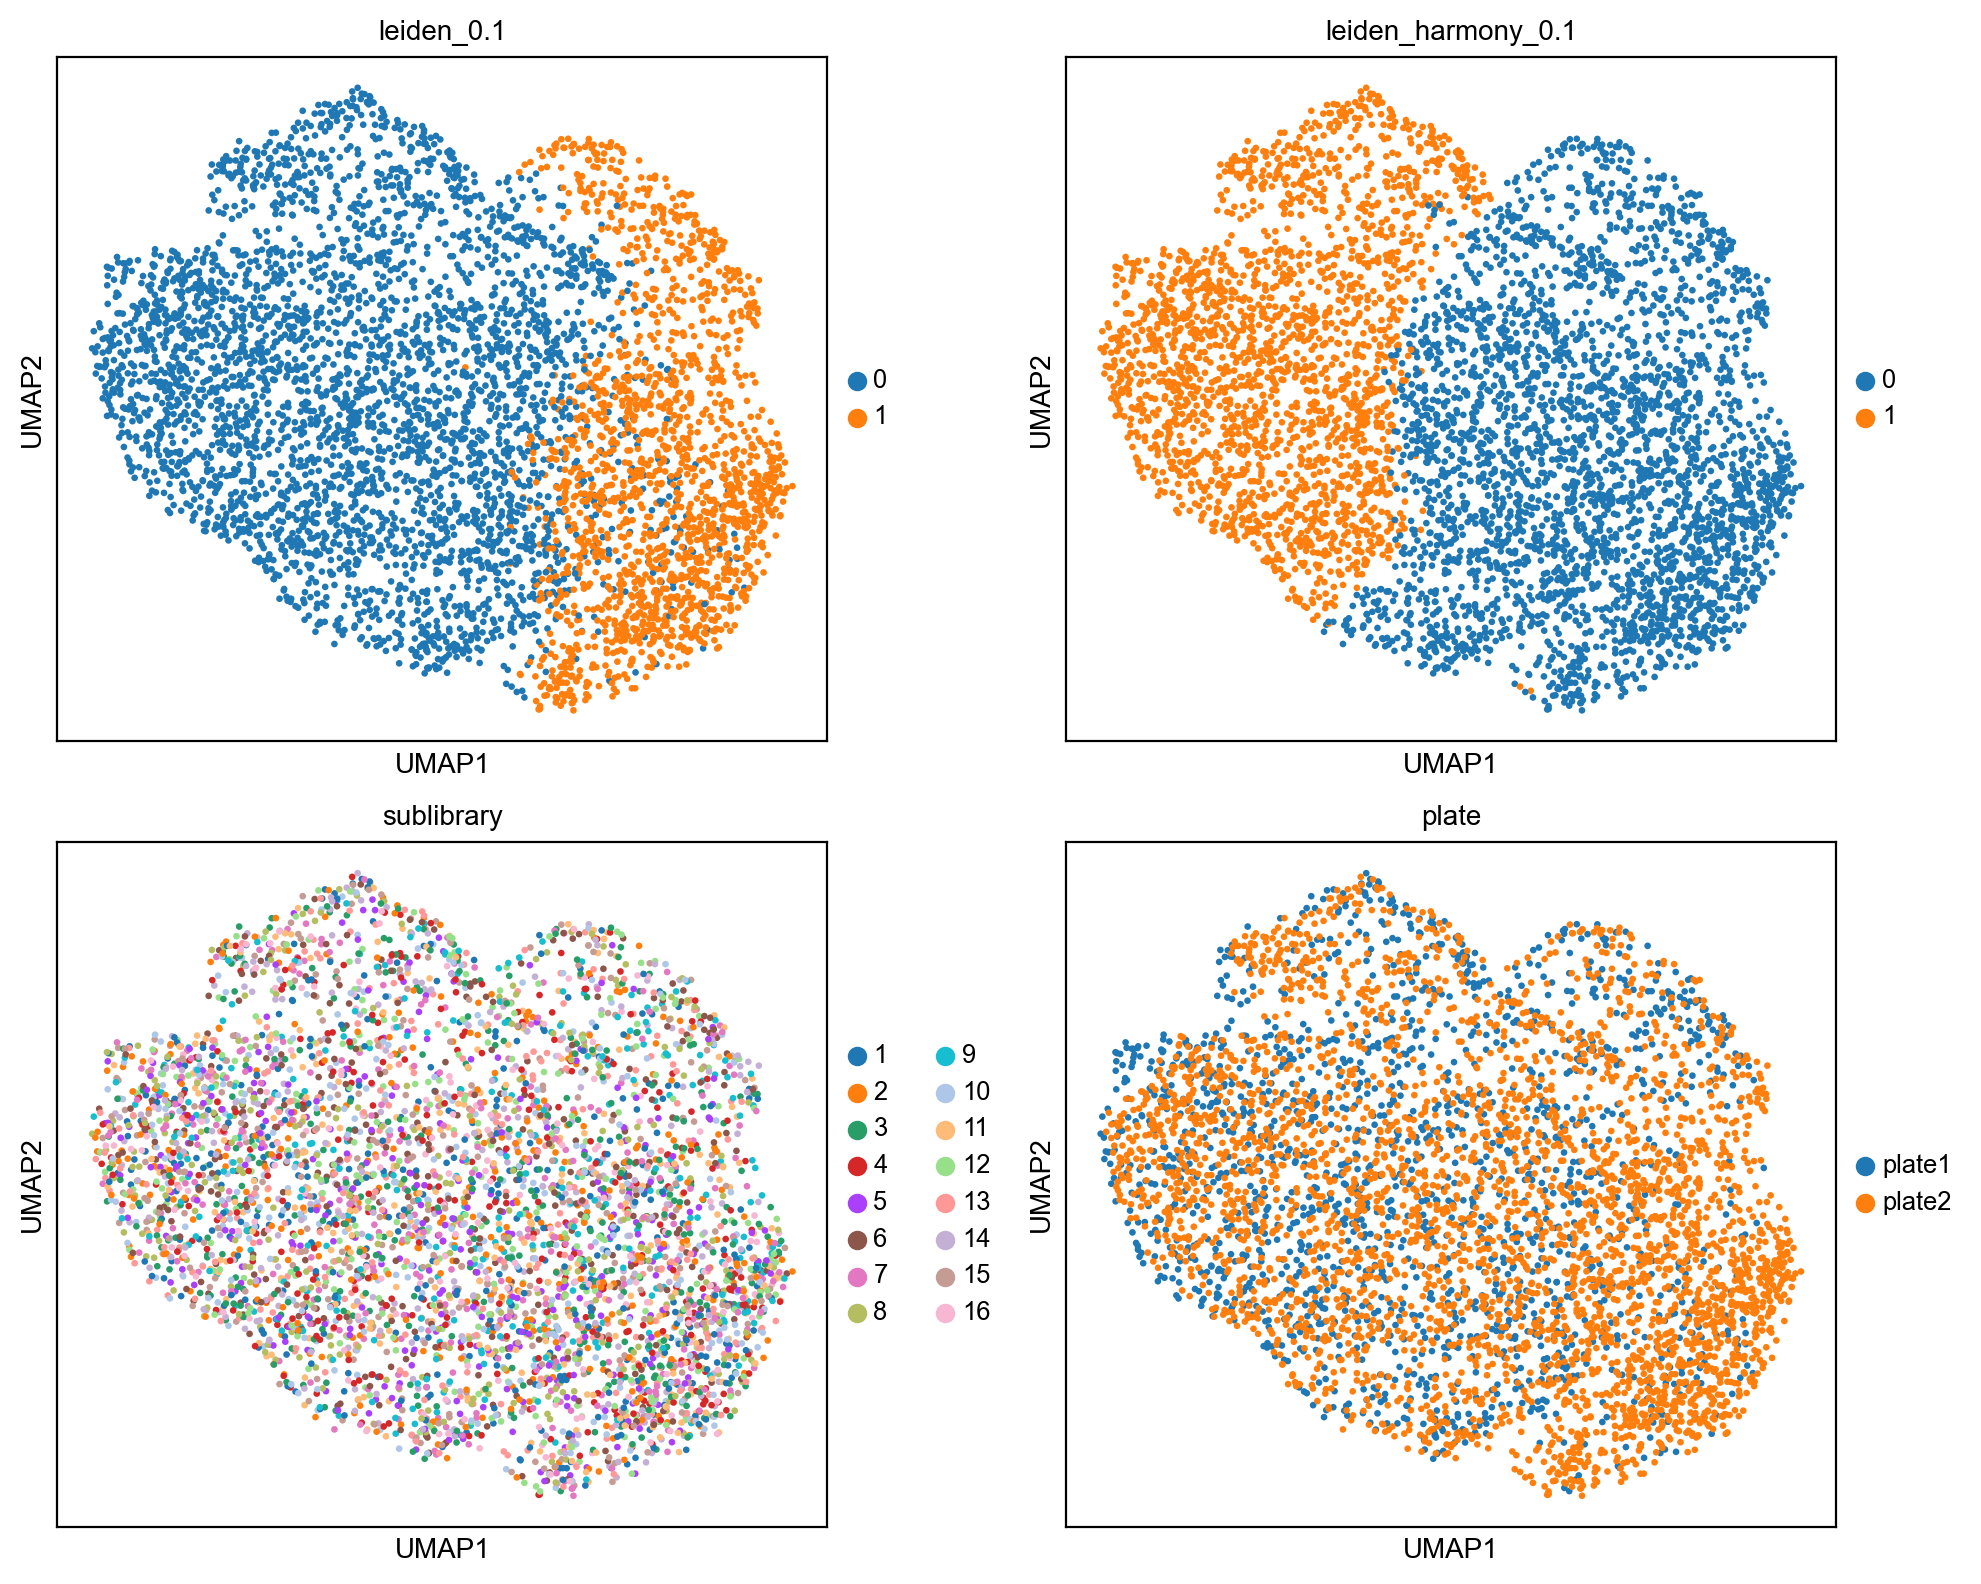

In [6]:
# UMAP
obs_columns = ['leiden_0.1', 'leiden_harmony_0.1', 'sublibrary', 'plate']
plot_umap_grid(adata, obs_columns, grid_size=(2, 2), figsize=(10, 8), save_path=None)


## Differential expressions

See: [nbisweden][def]

[def]: https://nbisweden.github.io/workshop-archive/workshop-scRNAseq/2020-01-27/labs/compiled/scanpy/scanpy_05_dge.html

ranking genes
    consider 'leiden_harmony_0.1' groups:
    with sizes: [3148 2077]
    finished: added to `.uns['t-test_ov']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


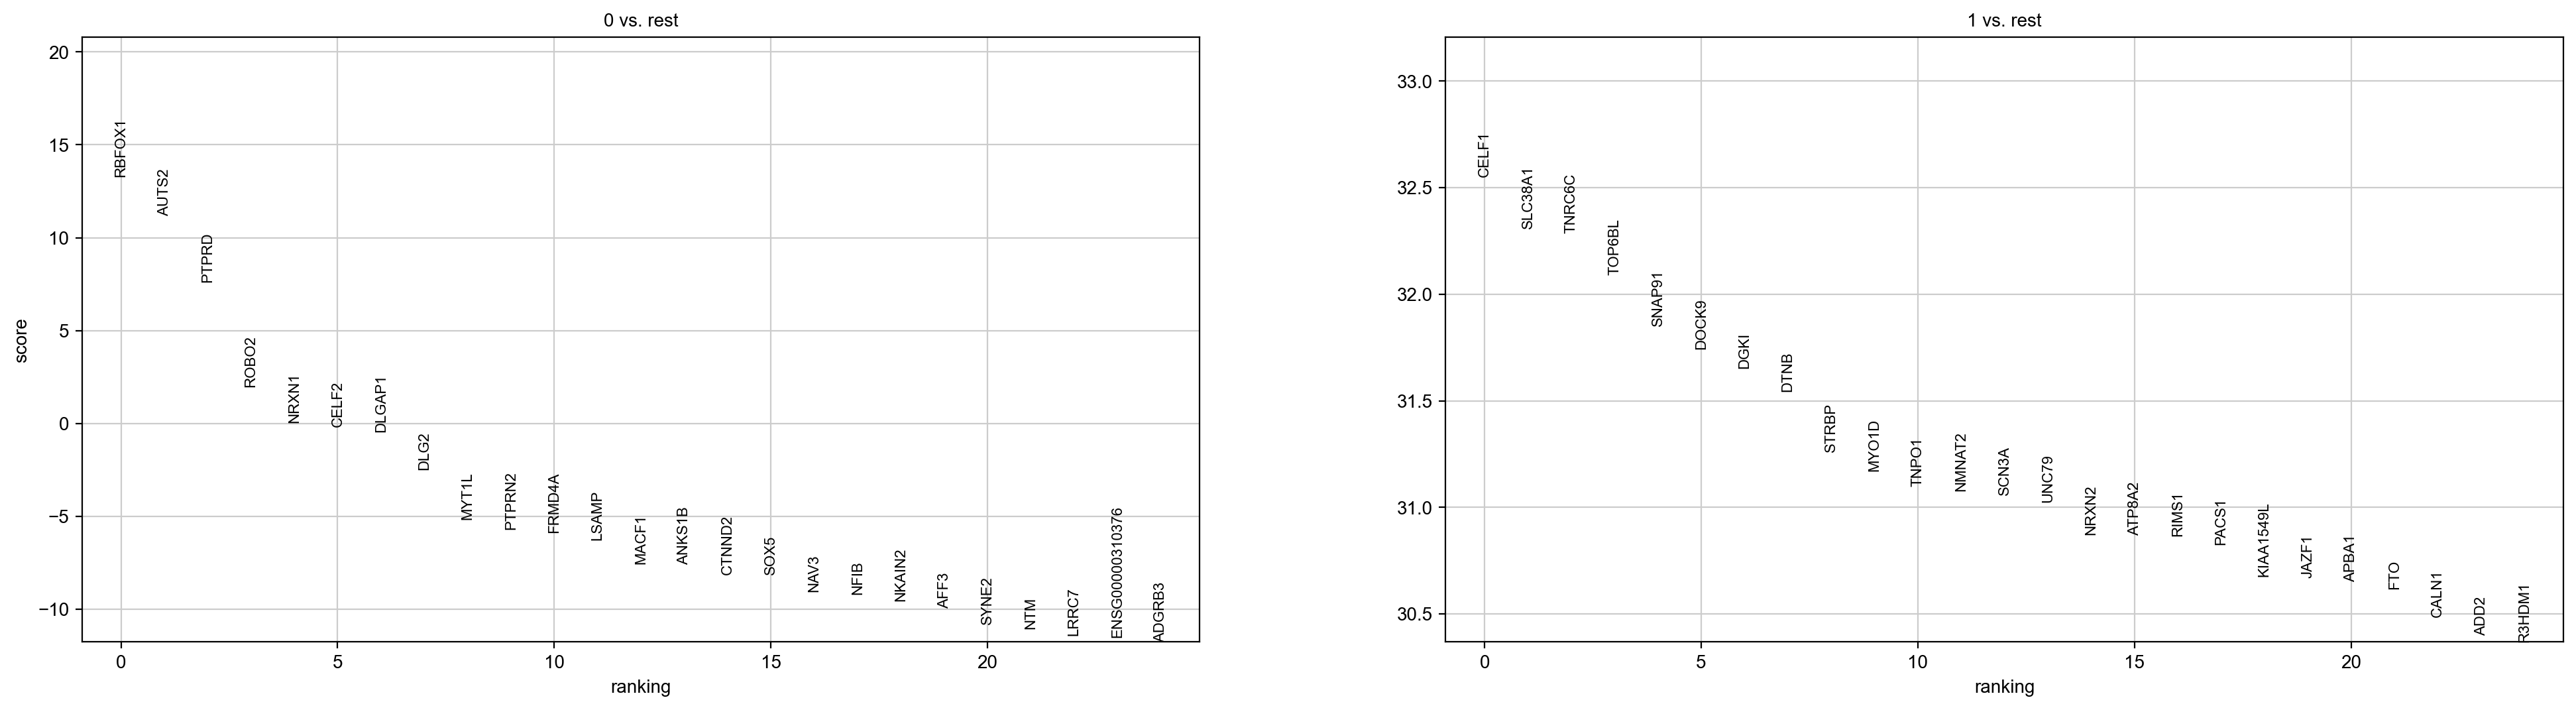

In [7]:
sc.tl.rank_genes_groups(adata, 'leiden_harmony_0.1', method='t-test_overestim_var', key_added = "t-test_ov")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test_ov")

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden_harmony_0.1']`


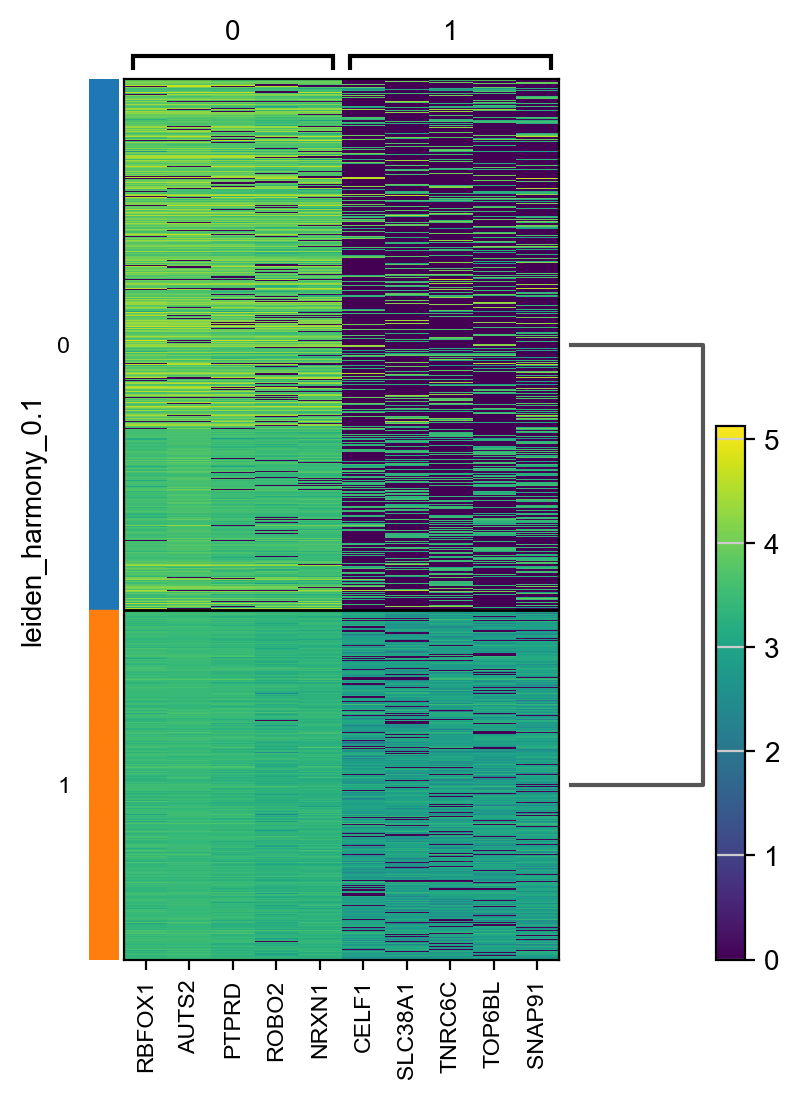

In [8]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, key="t-test_ov", groupby='leiden_harmony_0.1', show_gene_labels=True)

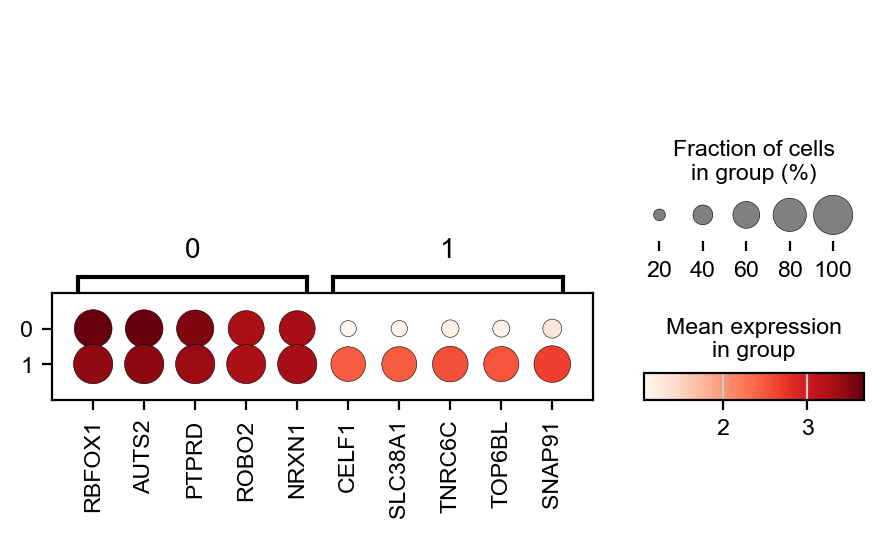

In [9]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, key="t-test_ov", groupby='leiden_harmony_0.1')

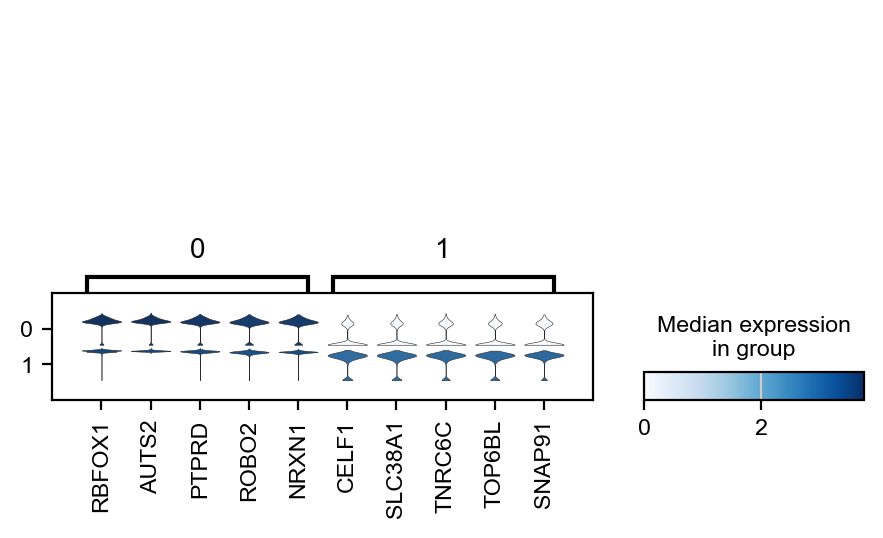

In [10]:
sc.pl.rank_genes_groups_stacked_violin(adata, n_genes=5, key="t-test_ov", groupby='leiden_harmony_0.1')

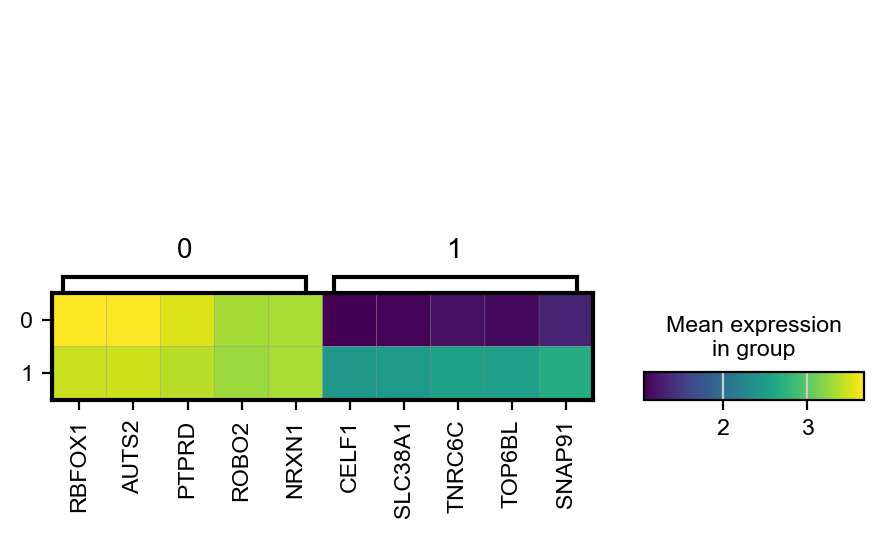

In [11]:
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=5, key="t-test_ov", groupby='leiden_harmony_0.1')